# Comparaison des performances entre Vision Transformers (ViT) et Convolutional Neural Networks (CNN) pour la classification d’images

---

## Objectif principal
Le but de ce notebook est de comparer les performances de deux architectures récentes, Vision Transformers (ViT) et Convolutional Neural Networks (CNN), sur des tâches de classification d'images. 

## Organisation du notebook

Ce notebook est organisé en 5 parties.
Nous commençons notre étude par la description et la visualision des datasets utilisés tout en justifiant le choix de ces derniers. 
Ensuite nous entrainerons et testerons les deux architectures CNN sur nos  datasets. 
Puis nous finirons en comparant les performances des deux modèles en prenant en compte les performances de classification, de temps d'entainement, de puissance de calcul et de mémoire.



In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Choix des datasets

Nous allons prendre les datasets **CIFAR-10** et **Hymenotera** car ils sont facilement téléchargeables et semblent adaptés au projet. On utilise pytorch pour ce notebook.

## Description des datasets utilisés

| Dataset | Description | Taille des images | Nombre de classes | Exemples de classes | Nombre d'images
| :--- | :--- | :--- | :--- | :--- | :--- |
| **CIFAR-10** | Dataset d'images couleur d'objets divers, plus complexe et varié que MNIST. | 32x32 pixels | 10 | Avion, Voiture, Oiseau, Chat, Cerf, Chien, Grenouille, Cheval, Bateau, Camion | 60 000 |
| **Hymenoptera** | Fourmis vs Abeilles. | 224x224 pixels | 2 | Fourmis, Abeilles | 400 |


- CIFAR-10 : disponible directement avec torch
- Hymenoptera : à télécharger ici -> https://www.kaggle.com/datasets/thedatasith/hymenoptera

Ils sont trop gros pour être mis sur le git, donc il faut les télécharger sur votre ordinateur en local. Le dossier gitignore gère cela.


In [2]:
## Import des fonctions nécessaires définies dans les différents fichier python
import prepa_dataset
import train
import Test_functions
from Test_functions import get_predictions, compute_accuracy, plot_confusion_matrix
import Custom_ResNet
import Custom_ViT
import Compare
import interpretabilite
import random

## Préparation des données

### Préparation de Hymenoptera

In [3]:
import kagglehub
import os
from torchvision import transforms
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import random_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [5]:
path_hymenoptera = kagglehub.dataset_download("thedatasith/hymenoptera")+"/hymenoptera"

print("Path to hymenoptera dataset files:", path_hymenoptera)

train_path_hymenoptera = os.path.join(path_hymenoptera, 'train')
test_path_hymenoptera = os.path.join(path_hymenoptera, 'val')

Path to hymenoptera dataset files: /home/davodeau/.cache/kagglehub/datasets/thedatasith/hymenoptera/versions/5/hymenoptera


In [6]:
# Transformation pour Hymenoptera car taille des images variées
hym_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
#Chargement des données
x_train, y_train, class_names_hym = prepa_dataset.load_folder_to_tensors(train_path_hymenoptera, hym_transforms)
x_test, y_test, class_names_hym = prepa_dataset.load_folder_to_tensors(test_path_hymenoptera, hym_transforms)


Afin de respecter une la répartition 80% train, 10% val et 10% test nous rassemblons les données pour ensuite créer les datasets avec la bonne répartition.
Nous vérifions également que toutes les classes soient distribuées équitablement dans chaque échantillon

In [7]:

#Utilise torch.cat car les données sont des tensors
x_total = torch.cat([x_train, x_test], dim=0)
y_total = torch.cat([y_train, y_test], dim=0)

print(f"Nombre total d'images: {len(x_total)}")


# Division 1
x_train_hymenoptera, x_transition, y_train_hymenoptera, y_transition = train_test_split(
    x_total, y_total, 
    test_size=0.2,  
    random_state=42,
    stratify=y_total  # Maintient la distribution des classes
)

# Division 2
x_val_hymenoptera, x_test_hymenoptera, y_val_hymenoptera, y_test_hymenoptera = train_test_split(
    x_transition, y_transition,
    test_size=0.5,  
    random_state=42,
    stratify=y_transition
)


print(f"Train: {len(x_train_hymenoptera)} images")
print(f"Validation: {len(x_val_hymenoptera)} images ")
print(f"Test: {len(x_test_hymenoptera)} images")


print(f"\nDistribution des classes dans train: {np.bincount(y_train_hymenoptera)}")
print(f"Distribution des classes dans validation: {np.bincount(y_val_hymenoptera)}")
print(f"Distribution des classes dans test: {np.bincount(y_test_hymenoptera)}")


Nombre total d'images: 397
Train: 317 images
Validation: 40 images 
Test: 40 images

Distribution des classes dans train: [154 163]
Distribution des classes dans validation: [19 21]
Distribution des classes dans test: [20 20]


### Préparation de CIFAR-10

In [8]:


cifar_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    transform=cifar_transforms,
    download=True
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    transform=cifar_transforms,
    download=True
)

val_ratio = 0.2
n_total = len(full_train_dataset)
n_val = int(val_ratio * n_total)
n_train = n_total - n_val
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [n_train, n_val]
)


# --- Conversion en tensors X et y ---
# --- Train ---
x_train_cifar10 = torch.stack([data[0] for data in train_dataset])
y_train_cifar10 = torch.tensor([data[1] for data in train_dataset])

# --- Validation ---
x_val_cifar10 = torch.stack([data[0] for data in val_dataset])
y_val_cifar10 = torch.tensor([data[1] for data in val_dataset])

# --- Test ---
x_test_cifar10 = torch.stack([data[0] for data in test_dataset])
y_test_cifar10 = torch.tensor([data[1] for data in test_dataset])

print(x_train_cifar10.shape)
print(x_val_cifar10.shape)
print(x_test_cifar10.shape)

cifar_classes = full_train_dataset.classes


torch.Size([40000, 3, 32, 32])
torch.Size([10000, 3, 32, 32])
torch.Size([10000, 3, 32, 32])


### Découpage des datasets en batches de taille 64 et changement du type pour la crossentropy

In [9]:

#Transformation en data loader avec des batches de taille 64
def get_dataloaders(x, y, batch_size=64, shuffle=True):
    # CrossEntropyLoss attend des labels de type long 
    if not isinstance(y, torch.LongTensor):
        y = y.long()
        
    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader


train_loader_cifar = get_dataloaders(x_train_cifar10, y_train_cifar10, batch_size=64, shuffle=True)
val_loader_cifar   = get_dataloaders(x_val_cifar10, y_val_cifar10, batch_size=64, shuffle=False)
test_loader_cifar   = get_dataloaders(x_test_cifar10, y_test_cifar10, batch_size=64, shuffle=False)

train_loader_hym = get_dataloaders(x_train_hymenoptera, y_train_hymenoptera, batch_size=32, shuffle=True)
val_loader_hym   = get_dataloaders(x_val_hymenoptera, y_val_hymenoptera, batch_size=32, shuffle=False)
test_loader_hym   = get_dataloaders(x_test_hymenoptera, y_test_hymenoptera, batch_size=32, shuffle=False)

# Visualisation des datasets

### hymenoptera

----- Dataset Description -----
Train data: 317 images
Dimensions détectées : 224x224 pixels, 3 canaux
Format PyTorch (Channels First) : Oui
Number of classes: 2
--------------------------------


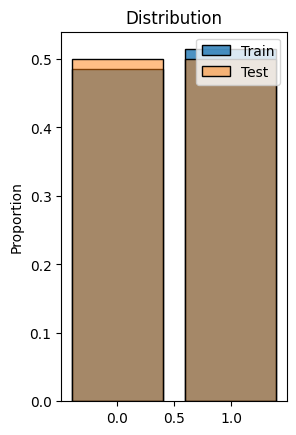

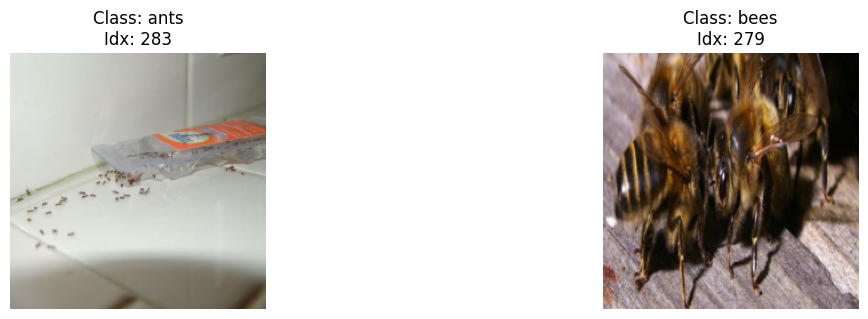

In [10]:
prepa_dataset.describe_image_dataset(
    x_train_hymenoptera, y_train_hymenoptera,
    x_test_hymenoptera, y_test_hymenoptera,
    class_names=class_names_hym,
    cmap=None
)

### CIFAR-10

----- Dataset Description -----
Train data: 40000 images
Dimensions détectées : 32x32 pixels, 3 canaux
Format PyTorch (Channels First) : Oui
Number of classes: 10
--------------------------------


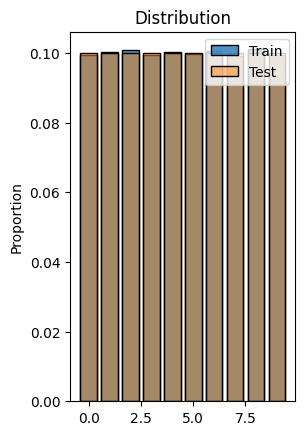

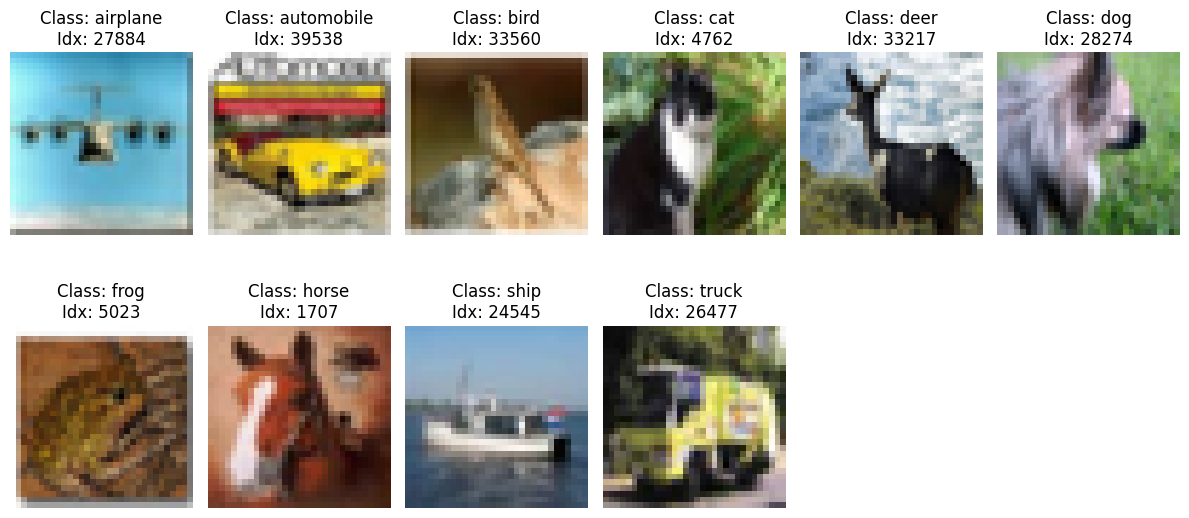

In [11]:
prepa_dataset.describe_image_dataset(
    x_train_cifar10, y_train_cifar10,
    x_test_cifar10, y_test_cifar10,
    class_names=cifar_classes,
    cmap=None
)

# Convolutional Neural Network (CNN or ConvNet)

On va commencer par la classification par CNN

## Data format

L'architecture de convolution prend en entrée des **images** et non des vecteurs 1D. Un certain formatage des données reste nécessaire.

Une **troisième dimension** est requise : la dimension des **canaux** (ou *channels*), qui permet de décrire chaque pixel.
- Pour les images en couleur, chaque pixel est codé par **plusieurs valeurs** (canaux **RGB** : Rouge, Vert, Bleu).

Ainsi, il est nécessaire de **redimensionner** les images :
- Pour CIFAR-10 : passer d'une dimension **$32 \times 32$** à **$32 \times 32 \times 3$** (pour inclure les 3 canaux RGB)
- Pour Hymenoptera : passer d'une dimension **$224 \times 224$** à **$224 \times 224 \times 3$** (pour inclure les 3 canaux RGB)

## Achitecture pour des images de couleurs

### Architecture du Modèle : Custom ResNet

Pour améliorer les performances et la stabilité de l'apprentissage par rapport à un CNN séquentiel classique (type VGG), nous implémentons une architecture basée sur **ResNet (Residual Network)**.

#### 1. Le Bloc Résiduel (`ResidualBlock`)
L'innovation principale de cette architecture est l'introduction de **connexions résiduelles** (skip connections). Au lieu d'empiler simplement des couches de convolution, chaque bloc ajoute l'entrée originale $x$ à la sortie des convolutions $F(x)$ :

$$\text{Output} = \text{ReLU}(F(x) + x)$$

Cette technique permet :
* De combattre le problème de **disparition du gradient** (vanishing gradient) dans les réseaux profonds.
* D'apprendre plus facilement l'identité si une couche n'est pas nécessaire.

#### 2. Structure du `ResNetCustom`
Le réseau est structuré en 4 étapes principales augmentant progressivement la complexité sémantique (profondeur) tout en réduisant la dimension spatiale :

* **Initialisation :** Convolution $3 \times 3$ (64 filtres).
* **Layer 1 :** 64 filtres (taille spatiale inchangée).
* **Layer 2 :** 128 filtres (downsampling / 2).
* **Layer 3 :** 256 filtres (downsampling / 2).
* **Layer 4 :** 512 filtres (downsampling / 2).

#### 3. Adaptabilité Universelle (`AdaptiveAvgPool2d`)
Une spécificité importante de cette implémentation est l'utilisation de l'**Adaptive Average Pooling** en fin de réseau.
* Contrairement à un `Flatten` classique qui dépend de la taille d'entrée, cette couche force la sortie spatiale à **$1 \times 1$**, quelle que soit la taille de l'image en entrée.
* **Conséquence :** Ce même modèle peut être entraîné indifféremment sur **CIFAR-10** ($32 \times 32$ px) ou **Hymenoptera** ($224 \times 224$ px) sans modifier la couche linéaire finale (`fc`).

## Entrainement CNN sur les deux datasets

### 1er entrainement: CIFAR10

In [12]:
criterion = nn.CrossEntropyLoss()
model_resnet_cifar = Custom_ResNet.ResNetCustom(num_classes=10).to(device)
optimizer_resnet = torch.optim.Adam(model_resnet_cifar.parameters(), lr=0.001)


# On réinitialise l'optimizer pour être sûr (si tu relances la cellule)
optimizer_cifar = torch.optim.Adam(model_resnet_cifar.parameters(), lr=0.001)
num_epochs_cifar = 10  
history_cifar = train.train_model(
    model=model_resnet_cifar,
    train_loader=train_loader_cifar,
    val_loader=val_loader_cifar,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optimizer_cifar,
    num_epochs=num_epochs_cifar, 
    device=device
)

Démarrage de l'entraînement sur cuda pour 10 epochs
Epoch [1/10] Train Loss: 1.4271 Acc: 0.4787 | Val Loss: 1.1365 Acc: 0.5870
Epoch [2/10] Train Loss: 0.9350 Acc: 0.6678 | Val Loss: 1.0351 Acc: 0.6484
Epoch [3/10] Train Loss: 0.6939 Acc: 0.7554 | Val Loss: 0.7872 Acc: 0.7191
Epoch [4/10] Train Loss: 0.5423 Acc: 0.8104 | Val Loss: 0.7836 Acc: 0.7453
Epoch [5/10] Train Loss: 0.4315 Acc: 0.8496 | Val Loss: 0.5681 Acc: 0.8127
Epoch [6/10] Train Loss: 0.3349 Acc: 0.8830 | Val Loss: 0.5353 Acc: 0.8230
Epoch [7/10] Train Loss: 0.2431 Acc: 0.9133 | Val Loss: 0.5825 Acc: 0.8200
Epoch [8/10] Train Loss: 0.1874 Acc: 0.9330 | Val Loss: 0.5810 Acc: 0.8294
Epoch [9/10] Train Loss: 0.1352 Acc: 0.9529 | Val Loss: 0.7019 Acc: 0.8119
Epoch [10/10] Train Loss: 0.1039 Acc: 0.9637 | Val Loss: 0.6897 Acc: 0.8242
Entraînement terminé en 3m 50s


### 2ème entrainement: Hymenoptera

In [13]:

model_resnet_hym = Custom_ResNet.ResNetCustom(num_classes=2).to(device)
optimizer_resnet_hym = torch.optim.Adam(model_resnet_hym.parameters(), lr=0.001)

# Optimizer spécifique pour ce modèle
optimizer_hym = torch.optim.Adam(model_resnet_hym.parameters(), lr=0.001)
num_epochs_hym = 15  
history_hym = train.train_model(
    model=model_resnet_hym, 
    train_loader=train_loader_hym,
    val_loader=val_loader_hym,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optimizer_hym,
    num_epochs=num_epochs_hym,
    device=device
)

Démarrage de l'entraînement sur cuda pour 15 epochs
Epoch [1/15] Train Loss: 1.1209 Acc: 0.5079 | Val Loss: 0.8293 Acc: 0.4750
Epoch [2/15] Train Loss: 0.6619 Acc: 0.5931 | Val Loss: 0.9462 Acc: 0.4750
Epoch [3/15] Train Loss: 0.6274 Acc: 0.6562 | Val Loss: 0.7606 Acc: 0.5500
Epoch [4/15] Train Loss: 0.6102 Acc: 0.6877 | Val Loss: 0.8376 Acc: 0.6500
Epoch [5/15] Train Loss: 0.6147 Acc: 0.6782 | Val Loss: 0.7985 Acc: 0.5750
Epoch [6/15] Train Loss: 0.5686 Acc: 0.6909 | Val Loss: 0.7217 Acc: 0.6000
Epoch [7/15] Train Loss: 0.5726 Acc: 0.7003 | Val Loss: 0.7709 Acc: 0.6000
Epoch [8/15] Train Loss: 0.5714 Acc: 0.7161 | Val Loss: 0.7019 Acc: 0.7000
Epoch [9/15] Train Loss: 0.5566 Acc: 0.7003 | Val Loss: 0.7253 Acc: 0.6000
Epoch [10/15] Train Loss: 0.5581 Acc: 0.7319 | Val Loss: 0.7331 Acc: 0.6000
Epoch [11/15] Train Loss: 0.5466 Acc: 0.7319 | Val Loss: 0.6955 Acc: 0.6750
Epoch [12/15] Train Loss: 0.5583 Acc: 0.7098 | Val Loss: 0.7756 Acc: 0.6000
Epoch [13/15] Train Loss: 0.5331 Acc: 0.7256 

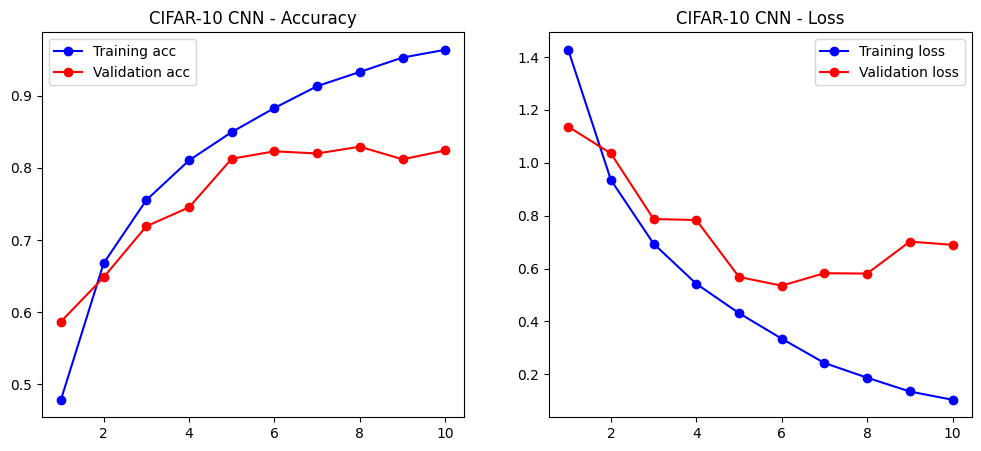

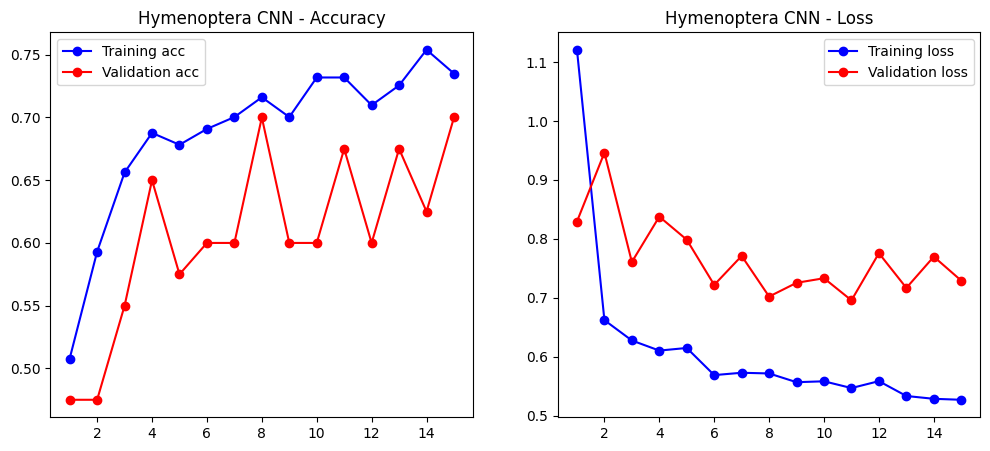

In [14]:
train.plot_history(history_cifar, title="CIFAR-10 CNN")
train.plot_history(history_hym, title="Hymenoptera CNN")

## Test du CNN sur les deux datasets

Précision (Accuracy): 0.8166 (81.66%)


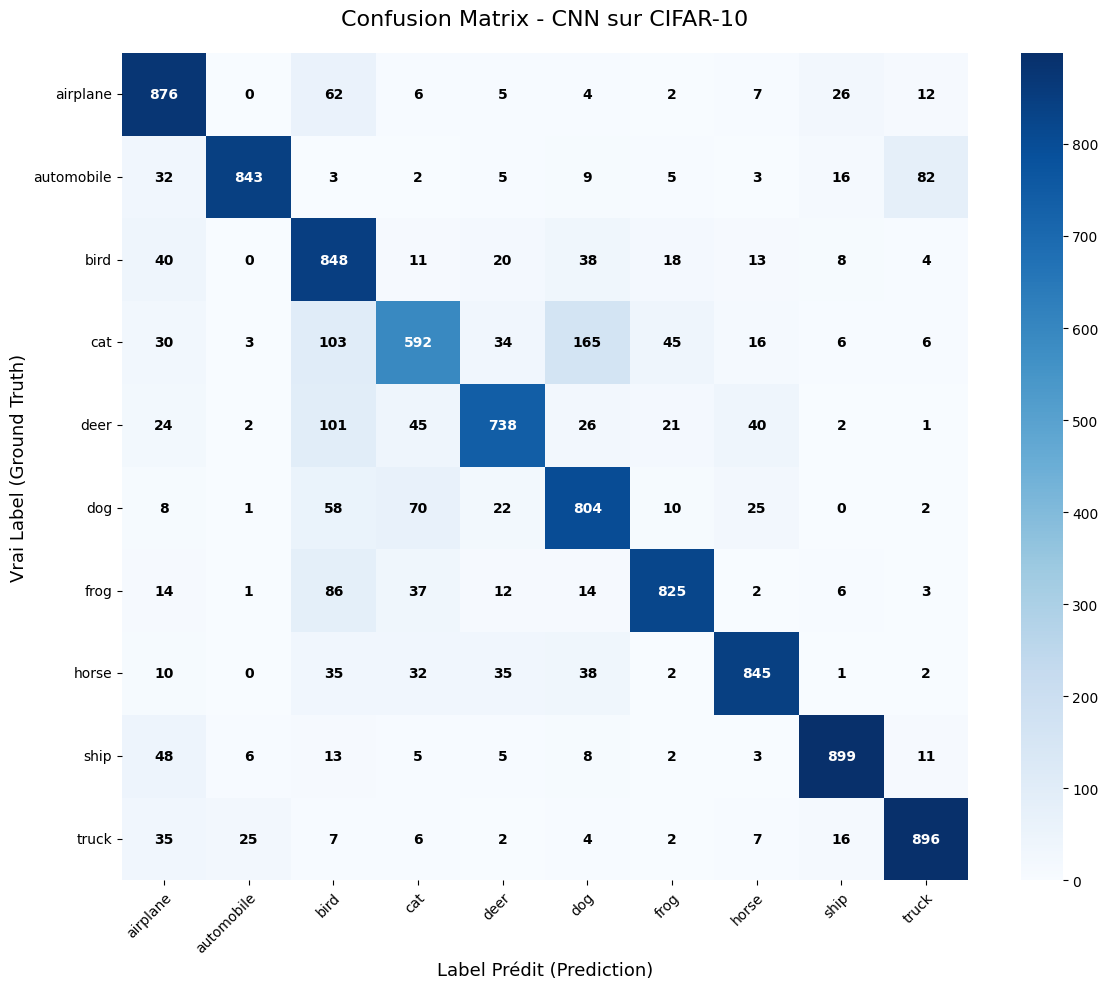

In [15]:
preds, labels = get_predictions(model_resnet_cifar, test_loader_cifar, device)

acc = compute_accuracy(labels, preds)

plot_confusion_matrix(labels, preds, cifar_classes, 
                      title="Confusion Matrix - CNN sur CIFAR-10")

Précision (Accuracy): 0.7500 (75.00%)


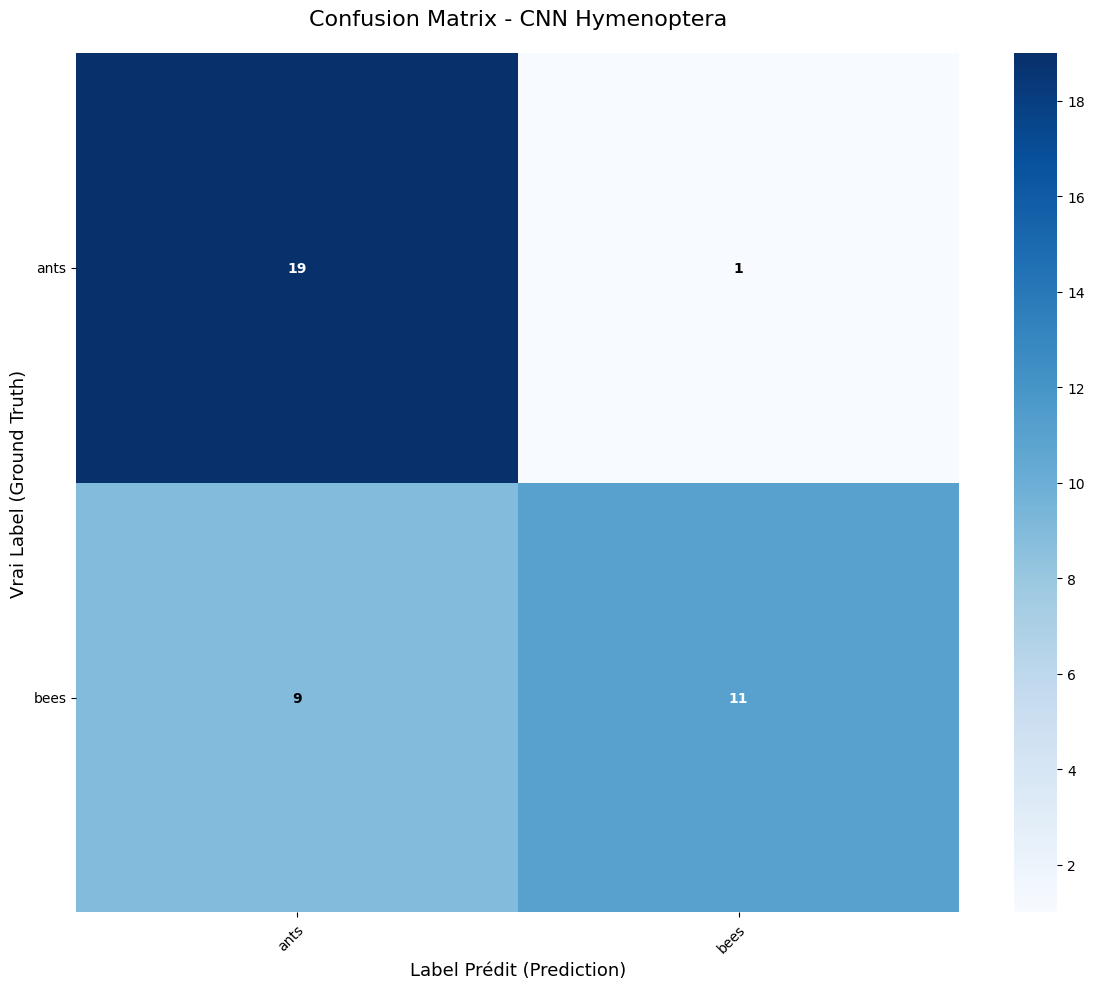

In [16]:
preds, labels = get_predictions(model_resnet_hym, test_loader_hym, device)

acc = compute_accuracy(labels, preds)

plot_confusion_matrix(labels, preds, class_names_hym, title="Confusion Matrix - CNN Hymenoptera")

# Modèle ViT

Maintenant nous allons entrainer un modèle ViT

## Compréhension du Vision Transformer (ViT)

Le ViT est une adaptation de l'architecture Transformer appliquée directement aux images. C'est une architecture **Encoder-Only**.

Contrairement aux CNN qui traitent les pixels via des fenêtres glissantes, le ViT traite l'image comme une séquence de tokens.

#### 1ère partie:Embedding
L'image est découpée en patches contenant chacun les valeurs des pixels (ex: pour du RGB 16x16, on a 16 x16 x 3 valeurs). 
En suite chaque patch est aplati en un vecteur 1D puis projeté avec une couche linéaire pour obtenir un vecteur de dimension latente fixe.

#### 2ème partie : Le Token CLS 

Un vecteur apprenable est ajouté au début de la séquence de patchs. Son rôle est d'intégrer l'information de tous les autres tokens via le mécanisme de Self-Attention Multi-Head. C'est ce vecteur qui sera utilisé pour prédire la classe. 

#### 3ème partie : Positional Embeddings 

L'information spatiale est réintroduite en ajoutant un vecteur de position à chaque embedding de patch. Ce sont des paramètres appris durant l'entraînement qui permettent de donner la position des patchs.

#### 4ème partie: Encodage avec le transformerblock
Une fois l'image convertie en une séquence de vecteurs de dimension latente, celle-ci traverse une série de blocs Transformer répétés. 

D'abord, un mécanisme de Self-Attention Multi-head permet à chaque vecteur de la séquence de capter et d'intégrer l'information contenue dans tous les autres vecteurs. Ensuite, un MLP projette chaque vecteur individuellement.

Pour stabiliser l'apprentissage, les opérations sont précédées d'une normalisation et d'une connexion résiduelle (addition du vecteur d'entrée avec le vecteur de sortie).

#### 5ème partie: Décision finale
À la sortie du dernier bloc Transformer, on utilise uniquement le vecteur correspondant au Token CLS.

Ce vecteur réprésente l'information globale de l'image. Il est normalisé et ensuite projeté par une couche linéaire vers la dimension du nombre de classes, avant d'être converti en probabilités avec la fonction softmax.

## Entrainement du ViT sur les deux datasets

#### Déclaration des modèles

Pour plus de lisibilité nous avons déclaré la classe ViT dans le fichier **Custom_ViT.py**

La taille standard des patches est de 16x16 pixels, qui est optimisée pour des images haute résolution (224x224). Appliqué aux images de CIFAR-10 (32x32 pixels), ce découpage ne générerait que 4 patches (2×2), ce qui est insuffisant pour que le mécanisme d'attention capture des dépendances spatiales.

Il faut donc réduire la taille des patches à 4x4 afin d'avoir un meilleur apprentissage pour CIFAR10.

In [17]:
print(f"Entraînement sur : {device}")

VIT_CONFIG = {
    'img_size': 224,      
    'patch_size': 16,     
    'embed_dim': 384,     
    'depth': 6,         
    'n_heads': 6,        
    'mlp_ratio': 4.0,
    'dropout': 0.1
}

VIT_CONFIG_cifar = {
    'img_size': 32,     
    'patch_size': 4,   # On change la taille des patchs !
    'embed_dim': 128,     
    'depth': 6,           
    'n_heads': 4,         
    'mlp_ratio': 4.0,
    'dropout': 0.1
}

model_vit_cifar = Custom_ViT.ViT(
    **VIT_CONFIG_cifar,
    in_channels=3,
    n_classes=10
).to(device)

model_vit_hym = Custom_ViT.ViT(
    **VIT_CONFIG,
    in_channels=3,
    n_classes=2
).to(device)

print("Modèles ViT initialisés.")

Entraînement sur : cuda
Modèles ViT initialisés.


### Entrainement sur CIFAR10

In [18]:
#Appelle du modèle si enregistré

save_path = "vit_cifar10_weights.pth"
optimizer_vit_cifar = optim.AdamW(model_vit_cifar.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = torch.nn.CrossEntropyLoss()


    
history_vit_cifar = train.train_model(
        model=model_vit_cifar,
        train_loader=train_loader_cifar,
        val_loader=val_loader_cifar,
        criterion=criterion,
        optimizer=optimizer_vit_cifar,
        num_epochs=10, 
        device=device
    )
    
# Sauvegarde des poids
torch.save(model_vit_cifar.state_dict(), save_path)
print(f"Modèle sauvegardé sous : {save_path}")

Démarrage de l'entraînement sur cuda pour 10 epochs
Epoch [1/10] Train Loss: 1.7860 Acc: 0.3442 | Val Loss: 1.5748 Acc: 0.4283
Epoch [2/10] Train Loss: 1.4782 Acc: 0.4666 | Val Loss: 1.3667 Acc: 0.5005
Epoch [3/10] Train Loss: 1.3037 Acc: 0.5281 | Val Loss: 1.2331 Acc: 0.5502
Epoch [4/10] Train Loss: 1.1986 Acc: 0.5694 | Val Loss: 1.1727 Acc: 0.5741
Epoch [5/10] Train Loss: 1.1233 Acc: 0.5979 | Val Loss: 1.1197 Acc: 0.5977
Epoch [6/10] Train Loss: 1.0686 Acc: 0.6162 | Val Loss: 1.0836 Acc: 0.6130
Epoch [7/10] Train Loss: 1.0202 Acc: 0.6363 | Val Loss: 1.0755 Acc: 0.6138
Epoch [8/10] Train Loss: 0.9771 Acc: 0.6503 | Val Loss: 1.0318 Acc: 0.6308
Epoch [9/10] Train Loss: 0.9386 Acc: 0.6649 | Val Loss: 1.0538 Acc: 0.6230
Epoch [10/10] Train Loss: 0.9040 Acc: 0.6787 | Val Loss: 1.0368 Acc: 0.6343
Entraînement terminé en 1m 52s
Modèle sauvegardé sous : vit_cifar10_weights.pth


### Entrainement sur Hymenoptera

In [19]:
save_path = "vit_Hymenoptera_weights.pth"
optimizer_vit_hym = optim.AdamW(model_vit_hym.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = torch.nn.CrossEntropyLoss()
  
history_vit_hym = train.train_model(
        model=model_vit_hym,
        train_loader=train_loader_hym,
        val_loader=val_loader_hym,
        criterion=criterion,
        optimizer=optimizer_vit_hym,
        num_epochs=10, 
        device=device
    )

torch.save(model_vit_hym.state_dict(), save_path)
print(f"Modèle sauvegardé sous : {save_path}")

Démarrage de l'entraînement sur cuda pour 10 epochs
Epoch [1/10] Train Loss: 0.8109 Acc: 0.5174 | Val Loss: 0.6927 Acc: 0.5750
Epoch [2/10] Train Loss: 0.6861 Acc: 0.5363 | Val Loss: 0.6864 Acc: 0.4750
Epoch [3/10] Train Loss: 0.6800 Acc: 0.5615 | Val Loss: 0.6866 Acc: 0.6000
Epoch [4/10] Train Loss: 0.6772 Acc: 0.5426 | Val Loss: 0.6837 Acc: 0.5750
Epoch [5/10] Train Loss: 0.6940 Acc: 0.5584 | Val Loss: 0.7184 Acc: 0.4750
Epoch [6/10] Train Loss: 0.6827 Acc: 0.5521 | Val Loss: 0.6850 Acc: 0.5500
Epoch [7/10] Train Loss: 0.6654 Acc: 0.6025 | Val Loss: 0.6991 Acc: 0.6000
Epoch [8/10] Train Loss: 0.6443 Acc: 0.6341 | Val Loss: 0.6579 Acc: 0.6250
Epoch [9/10] Train Loss: 0.6324 Acc: 0.6341 | Val Loss: 0.6271 Acc: 0.6000
Epoch [10/10] Train Loss: 0.5904 Acc: 0.7003 | Val Loss: 0.6144 Acc: 0.6750
Entraînement terminé en 0m 15s
Modèle sauvegardé sous : vit_Hymenoptera_weights.pth


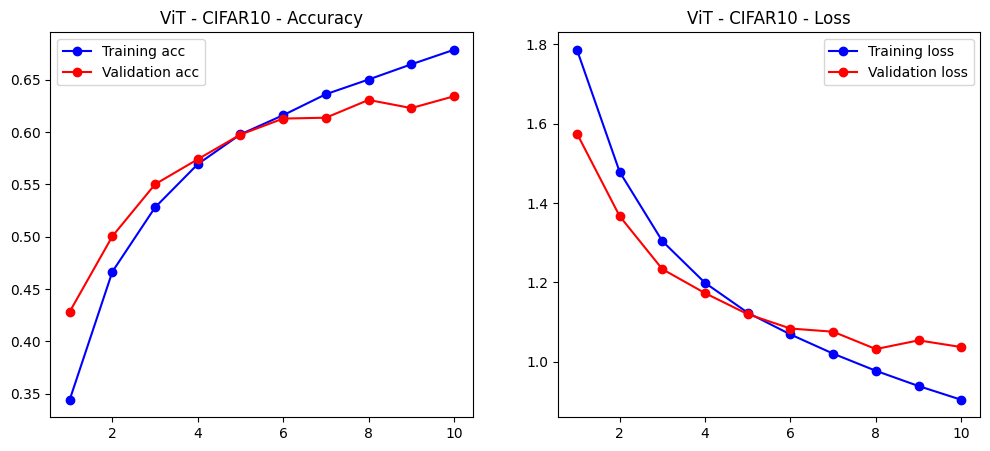

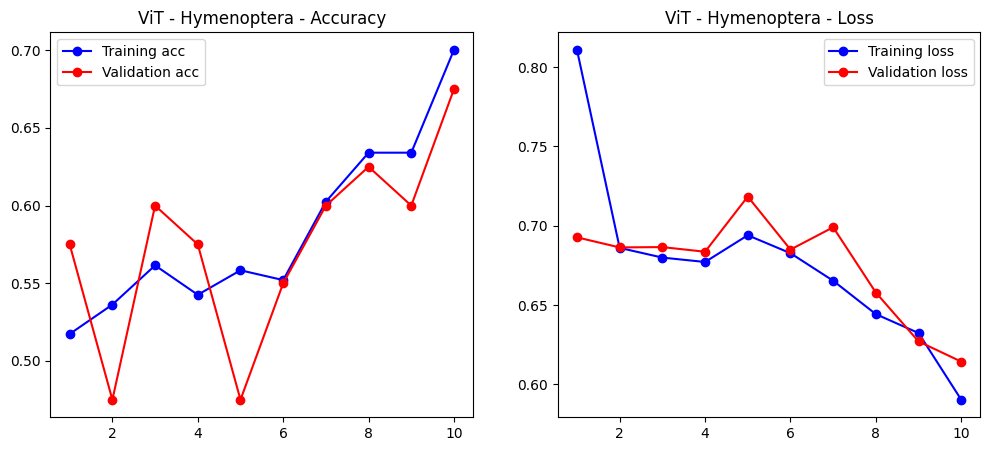

In [20]:
train.plot_history(history_vit_cifar, title="ViT - CIFAR10")
train.plot_history(history_vit_hym, title="ViT - Hymenoptera")

### Test du ViT sur les deux datasets 

Précision (Accuracy): 0.7500 (75.00%)


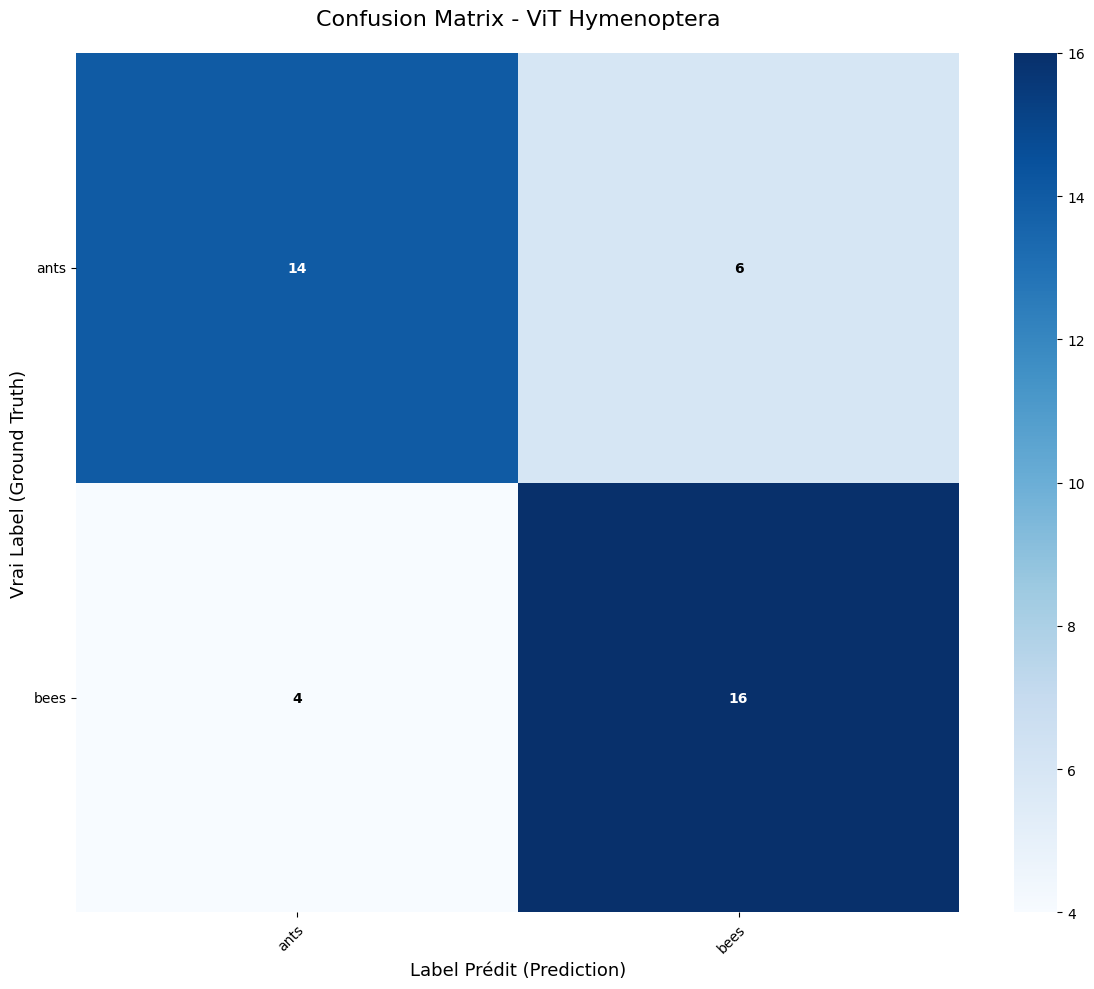

In [21]:
preds, labels = get_predictions(model_vit_hym, test_loader_hym, device)

acc = compute_accuracy(labels, preds)

plot_confusion_matrix(labels, preds, class_names_hym, title="Confusion Matrix - ViT Hymenoptera")

Précision (Accuracy): 0.6288 (62.88%)


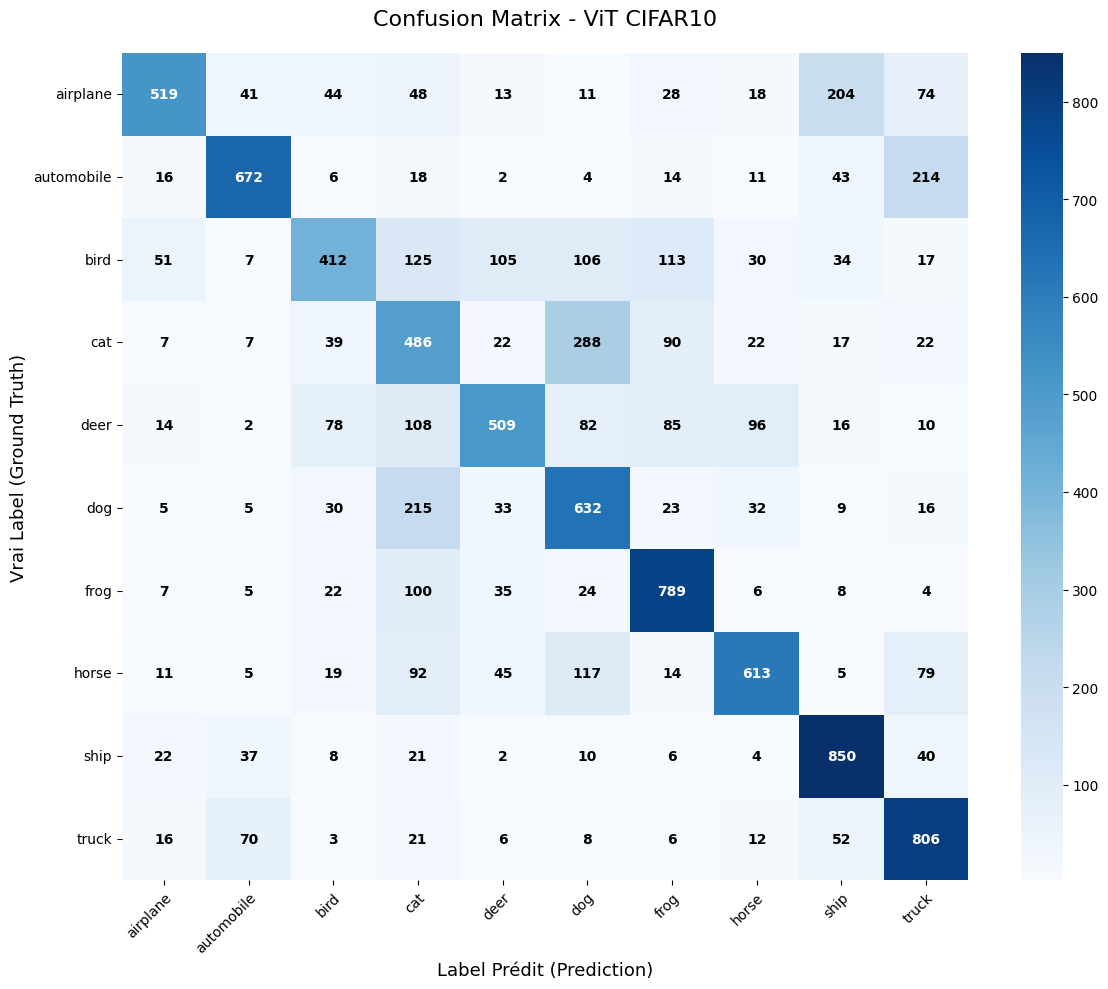

In [22]:
preds, labels = get_predictions(model_vit_cifar, test_loader_cifar, device)

acc = compute_accuracy(labels, preds)

plot_confusion_matrix(labels, preds, cifar_classes, title="Confusion Matrix - ViT CIFAR10")

# Comparaison des modèles

In [24]:
# 1. Récupération des accuracies si pas trouvé met 0
def get_acc(var_name, local_vars):
    if var_name in local_vars:
        # On prend la dernière valeur de validation (val_acc)
        return local_vars[var_name]['val_acc'][-1]
    return 0.0

#Récupération des variables pour chaque modèle et dataset 

acc_resnet_cifar = get_acc('history_cifar', locals())
acc_resnet_hym   = get_acc('history_hym', locals())
acc_vit_cifar    = get_acc('history_vit_cifar', locals())
acc_vit_hym      = get_acc('history_vit_hym', locals())


print(f"Accuracies récupérées :")
print(f"CNN Cifar: {acc_resnet_cifar:.2%}")
print(f"CNN Hym  : {acc_resnet_hym:.2%}")
print(f"ViT Cifar: {acc_vit_cifar:.2%}")
print(f"ViT Hym  : {acc_vit_hym:.2%})")


# Modèles à comparer
models_dict = {
    'ResNet_CIFAR10': model_resnet_cifar,
    'ResNet_Hymenoptera': model_resnet_hym,
    'ViT_CIFAR10': model_vit_cifar,
    'ViT_Hymenoptera': model_vit_hym
}

# 3. Input Shapes (Crucial pour le calcul des FLOPs)
input_shapes_dict = {
    'ResNet_CIFAR10': (1, 3, 32, 32),
    'ResNet_Hymenoptera': (1, 3, 224, 224),
    
    # Changez (1, 3, 224, 224) par (1, 3, 32, 32) si c'est la taille native de votre ViT
    'ViT_CIFAR10': (1, 3, 32, 32), 
    'ViT_Hymenoptera': (1, 3, 224, 224)
}

# Accuracies
accuracies_dict = {
    'ResNet_CIFAR10': acc_resnet_cifar,
    'ResNet_Hymenoptera': acc_resnet_hym,
    'ViT_CIFAR10': acc_vit_cifar,
    'ViT_Hymenoptera': acc_vit_hym
}

# Temps 
train_times_dict = {
    'ResNet_CIFAR10': 3*60+56.1, 'ResNet_Hymenoptera': 60+50.1,
    'ViT_CIFAR10': 34*60+47, 'ViT_Hymenoptera': 20.1
}

results = Compare.compare_models(
    models_dict=models_dict,
    input_shapes_dict=input_shapes_dict,
    accuracies_dict=accuracies_dict,
    train_times_dict=train_times_dict,
    device=device
)

Accuracies récupérées :
CNN Cifar: 82.42%
CNN Hym  : 70.00%
ViT Cifar: 63.43%
ViT Hym  : 67.50%)
COMPARAISON DES MODÈLES

Analyse de ResNet_CIFAR10...
  Input shape: (1, 3, 32, 32)
  ✓ Test Accuracy: 82.42%
  ✓ FLOPs: 1.12 GFLOPs
  ✓ Paramètres: 11.17 M
  ✓ Mémoire (inférence): 567.20 MB
  ✓ Mémoire (entraînement): 687.71 MB
  ✓ Temps d'entraînement: 236.10s

Analyse de ResNet_Hymenoptera...
  Input shape: (1, 3, 224, 224)
  ✓ Test Accuracy: 70.00%
  ✓ FLOPs: 54.67 GFLOPs
  ✓ Paramètres: 11.17 M
  ✓ Mémoire (inférence): 619.79 MB
  ✓ Mémoire (entraînement): 770.23 MB
  ✓ Temps d'entraînement: 110.10s

Analyse de ViT_CIFAR10...
  Input shape: (1, 3, 32, 32)
  ✓ Test Accuracy: 63.43%
  ✓ FLOPs: 0.10 GFLOPs
  ✓ Paramètres: 0.80 M
  ✓ Mémoire (inférence): 558.57 MB
  ✓ Mémoire (entraînement): 571.12 MB
  ✓ Temps d'entraînement: 2087.00s

Analyse de ViT_Hymenoptera...
  Input shape: (1, 3, 224, 224)
  ✓ Test Accuracy: 67.50%
  ✓ FLOPs: 2.91 GFLOPs
  ✓ Paramètres: 7.40 M
  ✓ Mémoire (inféren

# Fine Tuning ViT

## Interprétabilité ViT

--- Analyse ViT CIFAR-10 ---
Vraie classe : truck


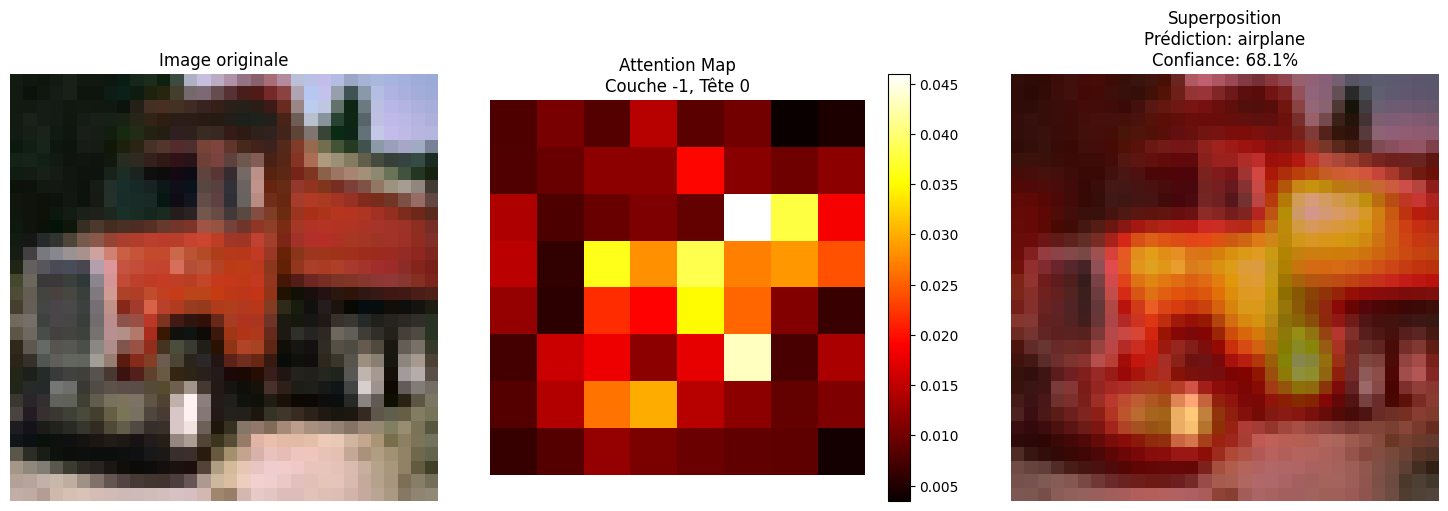

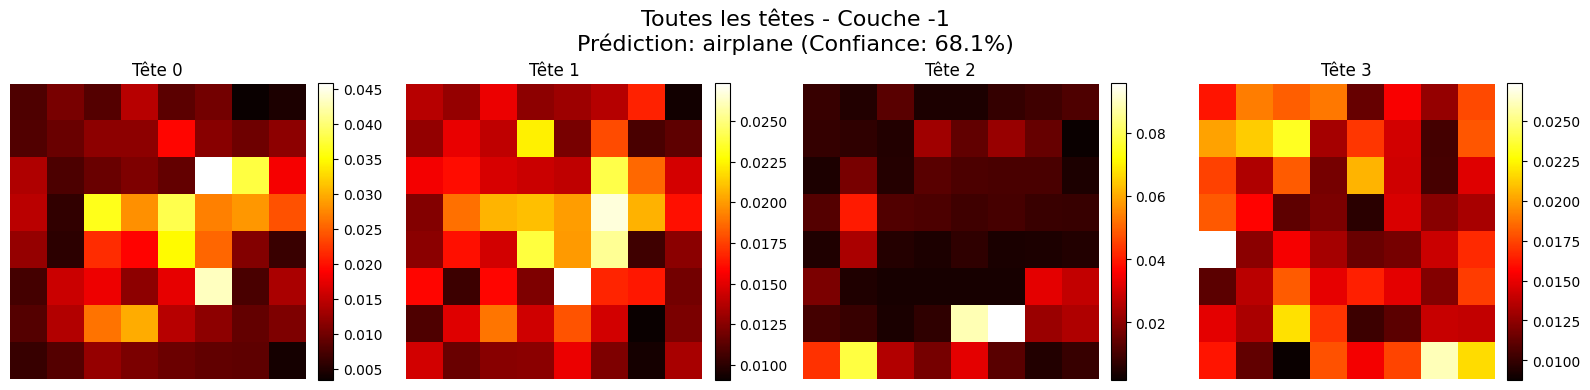

In [25]:


# 1. Instanciation de l'interpréteur
interpreter_cifar = interpretabilite.ViTInterpreter(model_vit_cifar, device)

# 2. Récupération d'une image de test CIFAR
# On prend le loader de validation défini précédemment
images, labels = next(iter(val_loader_cifar))
idx = random.randint(0, images.size(0) - 1)
image = images[idx]
label = labels[idx].item()
true_class_name = cifar_classes[label]

print(f"--- Analyse ViT CIFAR-10 ---")
print(f"Vraie classe : {true_class_name}")

# 3. Visualisation d'une tête spécifique (ex: Dernière couche, Tête 0)
# Cela montre où le modèle regarde "le plus" juste avant de décider
_ = interpreter_cifar.visualize_attention(
    image, 
    class_names=cifar_classes, 
    layer_idx=-1,  # Dernière couche
    head_idx=0     # Première tête d'attention
)

# 4. Visualisation de TOUTES les têtes de la dernière couche
# Permet de voir la diversité : certaines têtes regardent la forme, d'autres le fond, etc.
interpreter_cifar.visualize_all_heads(
    image, 
    class_names=cifar_classes, 
    layer_idx=-1
)